# 03 - Churn Model Development

This notebook walks through model development for the churn classifier using the same
features and configuration as the production pipeline.

**Prerequisites**:
- Run the ingestion and feature pipelines first (`make ingest`, `make features`).
- Ensure `features_train.csv` exists under `data/exports/`.

We will:
- Load engineered features and inspect the target.
- Train an XGBoost churn model (mirroring `src/models/churn_model.py`).
- Evaluate AUC-ROC and AUC-PR.
- Visualize feature importance.

In [2]:
import sys
import os

# Make sure the project root is on the path
sys.path.insert(0, os.path.abspath('..'))

os.chdir('..')  # run from project root, not notebooks/
print("Working directory:", os.getcwd())

Working directory: f:\Churn


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay

from src.utils.config import EXPORTS_DIR, CHURN_FEATURES

print(f"Using exports directory: {EXPORTS_DIR}")

Using exports directory: F:\Churn\data\exports


In [4]:
# Load training data
features_path = EXPORTS_DIR / "features_train.csv"
df = pd.read_csv(features_path)

available = [c for c in CHURN_FEATURES if c in df.columns]
missing = sorted(set(CHURN_FEATURES) - set(available))

print(f"Training rows: {len(df):,}")
print(f"Using {len(available)} features, missing {len(missing)}: {missing[:10]} ...")

X = df[available].fillna(0)
y = df["is_churn"].astype(int)

churn_rate = y.mean()
print(f"Churn rate: {churn_rate:.2%}")

Training rows: 860,967
Using 28 features, missing 0: [] ...
Churn rate: 9.46%


In [5]:
# Simple train/validation split for quick iteration
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,}")

Train: 688,773 | Val: 172,194


In [6]:
# Train an XGBoost model (mirrors src/models/churn_model.py hyperparameters in spirit)

params = {
    "n_estimators":     300,
    "max_depth":        6,
    "learning_rate":    0.05,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 10,
    "scale_pos_weight": max(1.0, (1 - churn_rate) / churn_rate),
    "eval_metric":      "aucpr",
    "random_state":     42,
}

model = xgb.XGBClassifier(**params)
model.fit(X_train, y_train)

y_val_proba = model.predict_proba(X_val)[:, 1]

auc_roc = roc_auc_score(y_val, y_val_proba)
auc_pr  = average_precision_score(y_val, y_val_proba)

print(f"Validation AUC-ROC: {auc_roc:.4f}")
print(f"Validation AUC-PR : {auc_pr:.4f}")

Validation AUC-ROC: 0.9113
Validation AUC-PR : 0.6955


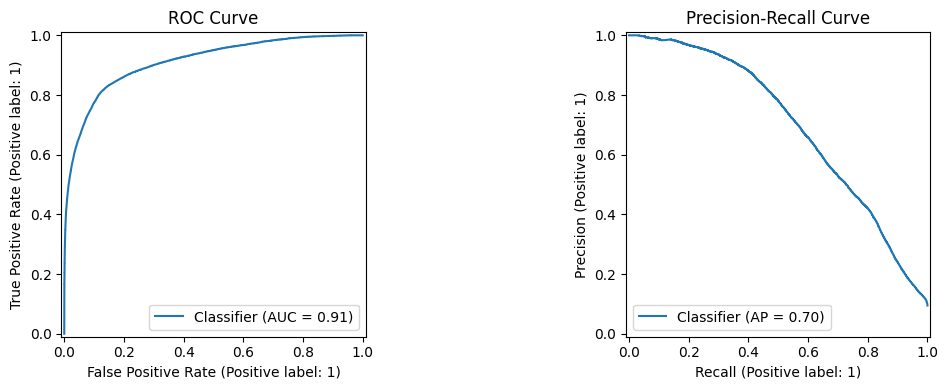

In [7]:
# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

RocCurveDisplay.from_predictions(y_val, y_val_proba, ax=axes[0])
axes[0].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_val, y_val_proba, ax=axes[1])
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()

,feature,importance
17,auto_renew_flag,0.551636
18,days_since_last_txn,0.076672
11,ticket_count_90d,0.062105
16,payment_failure_count_90d,0.050987
27,age_bucket_encoded,0.025919
10,ticket_count_30d,0.022885
3,sessions_last_30d,0.020576
26,city_encoded,0.019736
7,login_days_last_30d,0.017763
4,sessions_last_60d,0.017731


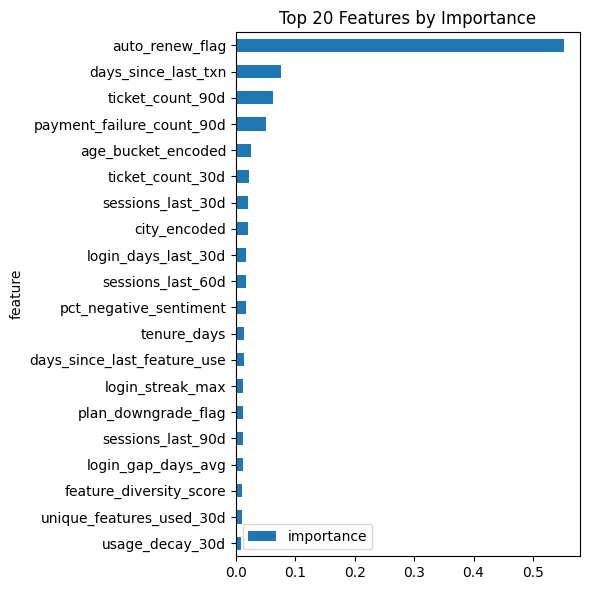

In [8]:
# Feature importance (gain-based)
importances = model.feature_importances_
feat_imp = (
    pd.DataFrame({"feature": available, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(6, 6))
feat_imp.plot.barh(x="feature", y="importance", ax=ax)
ax.invert_yaxis()
ax.set_title("Top 20 Features by Importance")
plt.tight_layout()
feat_imp

## Next steps

- Compare these notebook metrics with the production `src/models/churn_model.py` logs.
- Experiment with alternative hyperparameters or additional features.